In [1]:
## Load packages
from costs_benefits_ssp.cb_calculate import CostBenefits
import pandas as pd
from costs_benefits_ssp.model.cb_data_model import TXTable,CostFactor,TransformationCost,StrategyInteraction
import polars as pl
import os

In [ ]:
##---- Define Directories ----##
SCRIPT_DIR_PATH = os.getcwd()
PARENT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
OUTPUT_CB_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
CONFIG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "cb_config_files")
RUN_OUTPUT_DIR_PATH = os.path.join(PARENT_DIR_PATH, "ssp_run_output")

# REGULAR RUN
RUN_ID = "sisepuede_results_sisepuede_run_2026-01-30T20;56;40.308929"

# TORNADO RUN
# RUN_ID = "sisepuede_results_sisepuede_run_2026-01-30T21;12;12.498573"

# TRWW DEBUG RUN_ID
# RUN_ID = "sisepuede_results_sisepuede_run_2026-01-29T15;28;40.322709"

RUN_DIR_PATH = os.path.join(RUN_OUTPUT_DIR_PATH, RUN_ID)


In [3]:
# Make sure output directory exists
os.makedirs(OUTPUT_CB_PATH, exist_ok=True)

In [4]:
## Load the data
ssp_data = pd.read_csv(os.path.join(RUN_DIR_PATH, 
                                    "decomposed_ssp_output.csv"))
att_primary = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
att_strategy = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_STRATEGY.csv"))
print(f"Loaded ssp_data with {ssp_data.shape[0]} rows and {ssp_data.shape[1]} columns")
print(f"Loaded att_primary with {att_primary.shape[0]} rows and {att_primary.shape[1]} columns")
print(f"Loaded att_strategy with {att_strategy.shape[0]} rows and {att_strategy.shape[1]} columns")

Loaded ssp_data with 1392 rows and 4054 columns
Loaded att_primary with 48 rows and 4 columns
Loaded att_strategy with 126 rows and 6 columns


In [5]:
ssp_data.head()

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,yf_agrc_herbs_and_other_perennial_crops_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_other_annual_tonne_ha,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_pulses_tonne_ha,yf_agrc_rice_tonne_ha,yf_agrc_sugar_cane_tonne_ha,yf_agrc_tubers_tonne_ha,yf_agrc_vegetables_and_vines_tonne_ha,yf_lndu_supremum_pastures_tonne_per_ha
0,0,bulgaria,7,0,1.869757e+06,4493.247016,76487.740236,40316.177137,7558.127764,2.367448e+06,...,1.011737,0.509224,2.194576,0.5,1.937249,6.079400,55.765409,18.800200,2.759238,92.81
1,0,bulgaria,8,0,1.867011e+06,4486.648517,76375.415182,40256.971351,7547.028376,2.363971e+06,...,1.011737,0.380228,3.079152,0.5,1.578307,5.689031,55.765409,21.599397,2.875868,92.81
2,0,bulgaria,9,0,1.864295e+06,4480.119826,76264.278438,40198.391916,7536.046410,2.360531e+06,...,1.011737,0.380228,3.079152,0.5,1.578307,5.689031,55.765409,21.599397,2.875868,92.81
3,0,bulgaria,10,0,1.861622e+06,4473.697057,76154.944782,40140.762876,7525.242617,2.357147e+06,...,1.011737,0.380228,3.079152,0.5,1.578307,5.689031,55.765409,21.599397,2.875868,92.81
4,0,bulgaria,11,0,1.858993e+06,4467.379389,76047.400257,40084.076875,7514.615616,2.353819e+06,...,1.011737,0.380228,3.079152,0.5,1.578307,5.689031,55.765409,21.599397,2.875868,92.81


In [6]:
att_strategy.head()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0


In [7]:
att_strategy.tail()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
121,6066,WALI:INC_TREATMENT_RURAL_WAM,Singleton - WAM Value - WALI: Improved rural w...,NaN,TX:WALI:INC_TREATMENT_RURAL_STRATEGY_WAM,0
122,6067,WALI:INC_TREATMENT_URBAN_WAM,Singleton - WAM Value - WALI: Improved urban w...,NaN,TX:WALI:INC_TREATMENT_URBAN_STRATEGY_WAM,0
123,6057,PFLO:WAM_F,WAM_F,With Additional Measures and Forestry,TX:SOIL:DEC_N_APPLIED_STRATEGY_WAM_F|TX:WASO:I...,0
124,6058,PFLO:WAM_F_NO_CCS,WAM_F_NO_CCS,With Additional Measures and Foestry but No CCS,TX:WASO:INC_LANDFILLING_STRATEGY_WAM_F_NO_CCS|...,0
125,6059,PFLO:LSMM_BIOGAS_ACTIONS_WAM,Singleton - WAM Value - PFLO: LSMM actions to ...,NaN,TX:LSMM:INC_CAPTURE_BIOGAS_STRATEGY_WAM|TX:LSM...,0


In [8]:
att_primary

,primary_id,design_id,strategy_id,future_id
0,0,0,0,0
1,77077,0,6006,0
2,78078,0,6008,0
3,79079,0,6009,0
4,80080,0,6010,0
5,81081,0,6012,0
6,82082,0,6013,0
7,83083,0,6014,0
8,84084,0,6015,0
9,85085,0,6016,0


In [9]:
# Check for empty transformation_specification in att_strategy
mask_empty = att_strategy["transformation_specification"].isna() | (att_strategy["transformation_specification"].str.strip() == "")
if mask_empty.any():
    print("Warning: strategies with empty transformation_specification:", 
          att_strategy.loc[mask_empty, "strategy_code"].tolist())

In [10]:
## Define base strategy
# strategy_code_base = "PFLO:BAU"
strategy_code_base = "BASE"

In [11]:
# Check if strategy_code_base exists in att_strategy
if strategy_code_base not in att_strategy['strategy_code'].values:
    raise ValueError(f"Base strategy code '{strategy_code_base}' not found in att_strategy.")

### Some mods needed for cb to work propely

**Dec cement clinker**

In [12]:
# Create a new field for clinker
ssp_data["prod_ippu_clinker_tonne"] = ssp_data["prod_ippu_cement_tonne"] * ssp_data["frac_ippu_cement_clinker"]
ssp_data["prod_ippu_clinker_tonne"]

0       1.830433e+06
1       1.834396e+06
2       1.852522e+06
3       1.867148e+06
4       1.880962e+06
            ...     
1387    1.960897e+06
1388    1.960381e+06
1389    1.959672e+06
1390    1.958564e+06
1391    1.956894e+06
Name: prod_ippu_clinker_tonne, Length: 1392, dtype: float64

**hfc fix**

In [13]:
ef_hfc_fields = [col for col in ssp_data.columns if "ef_ippu_tonne_ch" in col and "electronics" in col]
ef_hfc_fields

['ef_ippu_tonne_ch2f2_per_tonne_production_electronics',
 'ef_ippu_tonne_ch3f_per_tonne_production_electronics',
 'ef_ippu_tonne_chf3_per_tonne_production_electronics']

In [14]:
# Create a new ef field for HFCs
ssp_data["ef_ippu_tonne_hfc_per_tonne_production_electronics"] = ssp_data[ef_hfc_fields].sum(axis=1)
ssp_data["ef_ippu_tonne_hfc_per_tonne_production_electronics"]

0       0.000928
1       0.000898
2       0.000868
3       0.000839
4       0.000809
          ...   
1387    0.000212
1388    0.000182
1389    0.000152
1390    0.000123
1391    0.000093
Name: ef_ippu_tonne_hfc_per_tonne_production_electronics, Length: 1392, dtype: float64

### Continue with the CB standard process

In [15]:
## Instantiate an object of the CostBenefits class
cb = CostBenefits(ssp_data, att_primary, att_strategy, strategy_code_base)

The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTr

In [16]:
# Once the excel file has been updated, we can reload it to update the cost factors database
cb.load_cb_parameters(os.path.join(CONFIG_DIR_PATH, "cb_config_params.xlsx"))

Cargamos configuración de archivo excel
Se actualizó la base de datos


In [17]:
# Compute System Costs
results_system = cb.compute_system_cost_for_all_strategies(verbose=False)


************************************
*Strategy : PFLO:INC_IND_CCS_WAM (0/47)
************************************


************************************
*Strategy : TRNS:SHIFT_MODE_PASSENGER_WAM (1/47)
************************************


************************************
*Strategy : ENTC:TARGET_RENEWABLE_ELEC_WAM (2/47)
************************************


************************************
*Strategy : WASO:INC_LANDFILLING_WAM (3/47)
************************************


************************************
*Strategy : WASO:INC_RECYCLING_WAM (4/47)
************************************


************************************
*Strategy : LSMM:INC_MANAGEMENT_POULTRY_WAM (5/47)
************************************


************************************
*Strategy : AGRC:DEC_CH4_RICE_WAM (6/47)
************************************


************************************
*Strategy : TRNS:SHIFT_FUEL_RAIL_WAM (7/47)
************************************


******************************

In [18]:
# Compute Technical Costs
results_tx = cb.compute_technical_cost_for_all_strategies(verbose=False)


************************************
*Strategy : PFLO:INC_IND_CCS_WAM (0/47)
************************************

La variable se evalúa en Transformation Cost

************************************
*Strategy : TRNS:SHIFT_MODE_PASSENGER_WAM (1/47)
************************************

The Strategy TRNS:SHIFT_MODE_PASSENGER_WAM hasn't technical costs

************************************
*Strategy : ENTC:TARGET_RENEWABLE_ELEC_WAM (2/47)
************************************

The Strategy ENTC:TARGET_RENEWABLE_ELEC_WAM hasn't technical costs

************************************
*Strategy : WASO:INC_LANDFILLING_WAM (3/47)
************************************

The Strategy WASO:INC_LANDFILLING_WAM hasn't technical costs

************************************
*Strategy : WASO:INC_RECYCLING_WAM (4/47)
************************************

The Strategy WASO:INC_RECYCLING_WAM hasn't technical costs

************************************
*Strategy : LSMM:INC_MANAGEMENT_POULTRY_WAM (5/47)
********

/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1074: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_merged_results["variable_value_baseline"] = 0
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1075: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_merged_results["variable_value_pathway"] = data_merged["difference_value"]
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.p


************************************
*Strategy : TRNS:SHIFT_MODE_REGIONAL_WAM (19/47)
************************************

The Strategy TRNS:SHIFT_MODE_REGIONAL_WAM hasn't technical costs

************************************
*Strategy : TRNS:INC_OCCUPANCY_LIGHT_DUTY_WAM (20/47)
************************************

The Strategy TRNS:INC_OCCUPANCY_LIGHT_DUTY_WAM hasn't technical costs

************************************
*Strategy : INEN:INC_EFFICIENCY_ENERGY_WAM (21/47)
************************************

La variable se evalúa en Transformation Cost

************************************
*Strategy : WASO:INC_ANAEROBIC_AND_COMPOST_WAM (22/47)
************************************

The Strategy WASO:INC_ANAEROBIC_AND_COMPOST_WAM hasn't technical costs

************************************
*Strategy : LSMM:INC_MANAGEMENT_OTHER_WAM (23/47)
************************************

La variable se evalúa en Transformation Cost

************************************
*Strategy : INEN:SHIFT_FUEL

/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1074: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_merged_results["variable_value_baseline"] = 0
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1075: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_merged_results["variable_value_pathway"] = data_merged["difference_value"]
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.p


************************************
*Strategy : WASO:INC_CAPTURE_BIOGAS_WAM (37/47)
************************************

La variable se evalúa en Transformation Cost

************************************
*Strategy : LNDU:INC_REFORESTATION_WAM (38/47)
************************************

La variable se evalúa en Transformation Cost

************************************
*Strategy : IPPU:DEC_CLINKER_WAM (39/47)
************************************

La variable se evalúa en Transformation Cost


####################################################################################################
[DEBUG] ENTER cb_ippu_clinker
[DEBUG] strategy_base: BASE
[DEBUG] strategy_tx: IPPU:DEC_CLINKER_WAM
[DEBUG] diff_var: prod_ippu_clinker_tonne
[DEBUG] output_variable_name: cb:ippu:technical_cost:clinker:X
[DEBUG] multiplier: 5.0
[DEBUG] annual_change: 1.0
####################################################################################################
[DEBUG] Using self.ssp_data
[DEBUG] ssp_d

/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1297: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_output["variable_value_baseline"] = 0
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1300: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_output["variable_value_pathway"] = data_merged["difference_value"]
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:856: SettingWi

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost

************************************
*Strategy : PFLO:WASO_BIOGAS_ACTIONS_WAM (42/47)
************************************

La variable se evalúa en Transformation Cost

************************************
*Strategy : PFLO:WALI_BIOGAS_ACTIONS_WAM (43/47)
************************************

The Strategy PFLO:WALI_BIOGAS_ACTIONS_WAM hasn't technical costs

************************************
*Strategy : PFLO:LSMM_BIOGAS_ACTIONS_WAM (44/47)
************************************

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost

************************************
*Strategy : WALI:INC_TREATMENT_RURAL_WAM (45/47)
************************************

The Strategy WALI:INC_TREATMENT_RURAL_WAM hasn't technical costs

************************************
*Strategy : WALI:

In [19]:
# Combine results
results_all = pd.concat([results_system, results_tx], ignore_index = True)

In [20]:
#-------------POST PROCESS SIMULATION RESULTS---------------
# Post process interactions among strategies that affect the same variables
results_all_pp = cb.cb_process_interactions(results_all)

# SHIFT any stray costs incurred from 2015 to 2025 to 2025 and 2035
results_all_pp_shifted = cb.cb_shift_costs(results_all_pp)


Resolving Interactions in SCOE :  
No interactions, skipping... PFLO:INC_IND_CCS_WAM
Resolving Interactions in INEN :  
No interactions, skipping... PFLO:INC_IND_CCS_WAM
Resolving Interactions in SCOE :  
No interactions, skipping... TRNS:SHIFT_MODE_PASSENGER_WAM
Resolving Interactions in INEN :  
No interactions, skipping... TRNS:SHIFT_MODE_PASSENGER_WAM
Resolving Interactions in SCOE :  
No interactions, skipping... ENTC:TARGET_RENEWABLE_ELEC_WAM
Resolving Interactions in INEN :  
No interactions, skipping... ENTC:TARGET_RENEWABLE_ELEC_WAM
Resolving Interactions in SCOE :  
No interactions, skipping... WASO:INC_LANDFILLING_WAM
Resolving Interactions in INEN :  
No interactions, skipping... WASO:INC_LANDFILLING_WAM
Resolving Interactions in SCOE :  
No interactions, skipping... WASO:INC_RECYCLING_WAM
Resolving Interactions in INEN :  
No interactions, skipping... WASO:INC_RECYCLING_WAM
Resolving Interactions in SCOE :  
No interactions, skipping... LSMM:INC_MANAGEMENT_POULTRY_WAM
Reso

/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:660: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_pre2025["variable"] = res_pre2025["variable"] + "_shifted" + (res_pre2025["time_period"]+SSP_GLOBAL_TIME_PERIOD_0).astype(str)#create a new variable so they can be recognized as shifted costs
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:661: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_pre2025["time_period"] =

In [21]:
results_all_pp_shifted

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value
0,PFLO:INC_IND_CCS_WAM,0.0,bulgaria,7.0,pop_unimproved_rural,772936.249506,772936.249506,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
1,PFLO:INC_IND_CCS_WAM,0.0,bulgaria,8.0,pop_unimproved_rural,758203.739880,758203.739880,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
2,PFLO:INC_IND_CCS_WAM,0.0,bulgaria,9.0,pop_unimproved_rural,752911.145955,752911.145955,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
3,PFLO:INC_IND_CCS_WAM,0.0,bulgaria,10.0,pop_unimproved_rural,746564.257886,746564.257886,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0
4,PFLO:INC_IND_CCS_WAM,0.0,bulgaria,11.0,pop_unimproved_rural,740262.204924,740262.204924,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0
...,...,...,...,...,...,...,...,...,...,...
254427,SCOE:SHIFT_FUEL_HEAT_WAM,0.0,bulgaria,18.0,energy_consumption_scoe_total,184.910076,184.910076,0.0,cb:scoe:technical_cost:fuel_switch:heat_pumps_...,0.0
254428,SCOE:SHIFT_FUEL_HEAT_WAM,0.0,bulgaria,19.0,energy_consumption_scoe_total,187.891968,187.891968,0.0,cb:scoe:technical_cost:fuel_switch:heat_pumps_...,0.0
254429,SCOE:SHIFT_FUEL_HEAT_WAM,0.0,bulgaria,17.0,energy_consumption_scoe_total,183.494541,183.494541,0.0,cb:scoe:technical_savings:fuel_switch:heat_pum...,-0.0
254430,SCOE:SHIFT_FUEL_HEAT_WAM,0.0,bulgaria,18.0,energy_consumption_scoe_total,184.910076,184.910076,0.0,cb:scoe:technical_savings:fuel_switch:heat_pum...,-0.0


In [22]:
results_all_pp_shifted.strategy_code.unique()

array(['PFLO:INC_IND_CCS_WAM', 'TRNS:SHIFT_MODE_PASSENGER_WAM',
       'ENTC:TARGET_RENEWABLE_ELEC_WAM', 'WASO:INC_LANDFILLING_WAM',
       'WASO:INC_RECYCLING_WAM', 'LSMM:INC_MANAGEMENT_POULTRY_WAM',
       'AGRC:DEC_CH4_RICE_WAM', 'TRNS:SHIFT_FUEL_RAIL_WAM',
       'ENTC:DEC_LOSSES_WAM', 'WASO:DEC_CONSUMER_FOOD_WASTE_WAM',
       'ENTC:TARGET_CLEAN_HYDROGEN_WAM', 'FGTV:DEC_LEAKS_WAM',
       'SCOE:DEC_DEMAND_HEAT_WAM', 'TRNS:SHIFT_MODE_FREIGHT_WAM',
       'LSMM:INC_CAPTURE_BIOGAS_WAM',
       'WASO:INC_ENERGY_FROM_INCINERATION_WAM', 'CCSQ:INC_CAPTURE_WAM',
       'IPPU:DEC_HFCS_WAM', 'LSMM:INC_MANAGEMENT_CATTLE_PIGS_WAM',
       'TRNS:SHIFT_MODE_REGIONAL_WAM',
       'TRNS:INC_OCCUPANCY_LIGHT_DUTY_WAM',
       'INEN:INC_EFFICIENCY_ENERGY_WAM',
       'WASO:INC_ANAEROBIC_AND_COMPOST_WAM',
       'LSMM:INC_MANAGEMENT_OTHER_WAM', 'INEN:SHIFT_FUEL_HEAT_WAM',
       'INEN:INC_EFFICIENCY_PRODUCTION_WAM', 'SOIL:DEC_N_APPLIED_WAM',
       'FGTV:INC_FLARE_WAM', 'SCOE:INC_EFFICIENCY_APPLIANCE

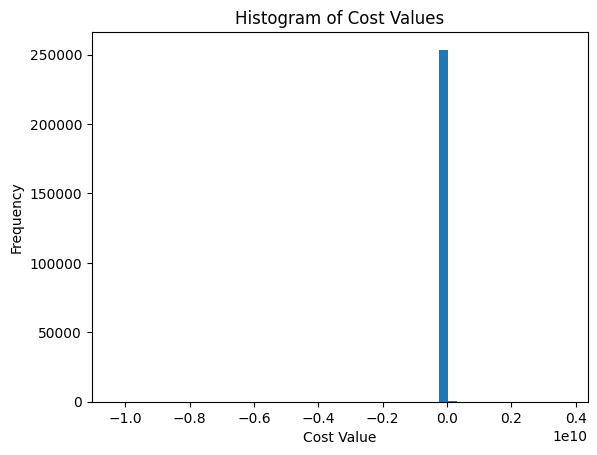

In [23]:
import matplotlib.pyplot as plt
plt.hist(results_all_pp_shifted.value, bins=50)
plt.title('Histogram of Cost Values')
plt.xlabel('Cost Value')
plt.ylabel('Frequency')
plt.show()

## Check for NaNs and Infs and DF Cleaning

In [24]:
# check nans
results_all_pp_shifted.value.isna().any()

np.False_

In [25]:
# check -inf or inf values
results_all_pp_shifted.value.isin([float('inf'), float('-inf')]).any()

np.False_

In [26]:
results_all_pp_shifted.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value
0,PFLO:INC_IND_CCS_WAM,0.0,bulgaria,7.0,pop_unimproved_rural,772936.249506,772936.249506,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
1,PFLO:INC_IND_CCS_WAM,0.0,bulgaria,8.0,pop_unimproved_rural,758203.739880,758203.739880,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
2,PFLO:INC_IND_CCS_WAM,0.0,bulgaria,9.0,pop_unimproved_rural,752911.145955,752911.145955,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
3,PFLO:INC_IND_CCS_WAM,0.0,bulgaria,10.0,pop_unimproved_rural,746564.257886,746564.257886,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0
4,PFLO:INC_IND_CCS_WAM,0.0,bulgaria,11.0,pop_unimproved_rural,740262.204924,740262.204924,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0


In [27]:
results_all_pp_shifted.to_csv(os.path.join(OUTPUT_CB_PATH, f"costs_benefits_{RUN_ID}_tornado_raw.csv"), index=False)

## Reshape to load into tableau

In [28]:
# --- Read cost-benefit data ---
cb_data = results_all_pp_shifted.copy()

# Split 'variable' into components: name, sector, cb_type, item_1, item_2
# (Assumes exactly 5 colon-separated parts; if there are more colons inside the last field,
# they will be kept in item_2 thanks to n=4)
cb_chars = cb_data["variable"].astype(str).str.split(":", n=4, expand=True)
cb_chars.columns = ["name", "sector", "cb_type", "item_1", "item_2"]
cb_data = pd.concat([cb_data, cb_chars], axis=1)

In [29]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2
0,PFLO:WEM,0.0,bulgaria,7.0,pop_unimproved_rural,772936.249506,772936.249506,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural
1,PFLO:WEM,0.0,bulgaria,8.0,pop_unimproved_rural,758203.739880,758203.739880,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural
2,PFLO:WEM,0.0,bulgaria,9.0,pop_unimproved_rural,752911.145955,752911.145955,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural
3,PFLO:WEM,0.0,bulgaria,10.0,pop_unimproved_rural,746564.257886,746564.257886,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0,cb,wali,technical_cost,sanitation,unimp_rural
4,PFLO:WEM,0.0,bulgaria,11.0,pop_unimproved_rural,740262.204924,740262.204924,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0,cb,wali,technical_cost,sanitation,unimp_rural


In [30]:
# Scale value from USD to billions (divide by 1e9)
if "value" in cb_data.columns:
    cb_data["value"] = cb_data["value"] / 1e9

# --- Remove "shifted" entries ---
# Remove rows where item_2 contains "shifted"
cb_data = cb_data[~cb_data["item_2"].astype(str).str.contains("shifted", na=False)]

# Remove any remaining rows where variable contains "shifted2"
cb_data = cb_data[~cb_data["variable"].astype(str).str.contains("shifted2", na=False)]

# --- Add Year column (Year = time_period + 2015) ---
cb_data["Year"] = cb_data["time_period"] + 2015

**This Section Needs Manual Tunnning**

In [31]:
cb_data.strategy_code.unique()

array(['PFLO:WEM', 'PFLO:WAM', 'PFLO:WAM_F', 'PFLO:WAM_F_NO_CCS'],
      dtype=object)

In [32]:
# Harmonize strategy name changes with a single mapping (no duplicate replacements)
strategy_name_map = {
    "PFLO:WEM": "With Existing Measures",
    "PFLO:WAM": "With Additional Measures",
    "PFLO:WAM_F": "With Additional Measures + Opportunities",
    "PFLO:WAM_F_NO_CCS": "With Additional Measures + Opportunities + No CCS"
}

cb_data["strategy"] = (
    cb_data["strategy_code"].astype(str).map(strategy_name_map).fillna(cb_data["strategy_code"])
)
print(cb_data["strategy"].unique())


['With Existing Measures' 'With Additional Measures'
 'With Additional Measures + Opportunities'
 'With Additional Measures + Opportunities + No CCS']


In [33]:
att_primary

,primary_id,design_id,strategy_id,future_id
0,0,0,0,0
1,74074,0,6003,0
2,75075,0,6004,0
3,122122,0,6057,0
4,123123,0,6058,0


In [34]:
# --- Strategy ID mapping based on strategy_code ---
def map_strategy_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:WEM":
        return 6003
    if code == "PFLO:WAM":
        return 6004
    if code == "PFLO:WAM_F":
        return 6057
    if code =="PFLO:WAM_F_NO_CCS":
        return 6058
    return code  # keep original if not matched

cb_data["strategy_id"] = cb_data["strategy_code"].astype(str).map(map_strategy_id)

In [35]:
ssp_data.primary_id.unique()

array([     0,  74074,  75075, 122122, 123123])

In [36]:
def map_primary_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:WEM":
        return 74074
    if code == "PFLO:WAM":
        return 75075
    if code == "PFLO:WAM_F":
        return 122122
    if code == "PFLO:WAM_F_NO_CCS":
        return 123123
    return code  # keep original if not matched

cb_data["primary_id"] = cb_data["strategy_code"].astype(str).map(map_primary_id)


**Manual Tunning Ends Here**

In [37]:
# --- Create ids (variable:strategy_id) ---
cb_data["ids"] = cb_data["variable"].astype(str) + ":" + cb_data["strategy_id"].astype(str)

In [38]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids
0,PFLO:WEM,0.0,bulgaria,7.0,pop_unimproved_rural,772936.249506,772936.249506,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural,2022.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...
1,PFLO:WEM,0.0,bulgaria,8.0,pop_unimproved_rural,758203.739880,758203.739880,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural,2023.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...
2,PFLO:WEM,0.0,bulgaria,9.0,pop_unimproved_rural,752911.145955,752911.145955,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural,2024.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...
3,PFLO:WEM,0.0,bulgaria,10.0,pop_unimproved_rural,746564.257886,746564.257886,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0,cb,wali,technical_cost,sanitation,unimp_rural,2025.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...
4,PFLO:WEM,0.0,bulgaria,11.0,pop_unimproved_rural,740262.204924,740262.204924,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0,cb,wali,technical_cost,sanitation,unimp_rural,2026.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...


In [39]:
cb_data.strategy.unique()

array(['With Existing Measures', 'With Additional Measures',
       'With Additional Measures + Opportunities',
       'With Additional Measures + Opportunities + No CCS'], dtype=object)

In [40]:
cb_data.strategy_code.unique()

array(['PFLO:WEM', 'PFLO:WAM', 'PFLO:WAM_F', 'PFLO:WAM_F_NO_CCS'],
      dtype=object)

In [41]:
cb_data.primary_id.unique()

array([ 74074,  75075, 122122, 123123])

In [42]:
# --- Read GDP and merge ---
# Keep only needed columns
gdp = ssp_data.loc[:, ["primary_id", "time_period", "gdp_mmm_usd"]]
gdp.head()

,primary_id,time_period,gdp_mmm_usd
0,0,7,174.310000
1,0,8,177.527763
2,0,9,183.563707
3,0,10,189.070618
4,0,11,194.553666


In [43]:
# Merge cb_data with gdp on primary_id and time_period
cb_data = cb_data.merge(gdp, on=["primary_id", "time_period"], how="left")
cb_data

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,...,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids,gdp_mmm_usd
0,PFLO:WEM,0.0,bulgaria,7.0,pop_unimproved_rural,772936.249506,772936.249506,0.000000,cb:wali:technical_cost:sanitation:unimp_rural,0.000000,...,wali,technical_cost,sanitation,unimp_rural,2022.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...,174.310000
1,PFLO:WEM,0.0,bulgaria,8.0,pop_unimproved_rural,758203.739880,758203.739880,0.000000,cb:wali:technical_cost:sanitation:unimp_rural,0.000000,...,wali,technical_cost,sanitation,unimp_rural,2023.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...,177.527763
2,PFLO:WEM,0.0,bulgaria,9.0,pop_unimproved_rural,752911.145955,752911.145955,0.000000,cb:wali:technical_cost:sanitation:unimp_rural,0.000000,...,wali,technical_cost,sanitation,unimp_rural,2024.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...,183.563707
3,PFLO:WEM,0.0,bulgaria,10.0,pop_unimproved_rural,746564.257886,746564.257886,0.000000,cb:wali:technical_cost:sanitation:unimp_rural,-0.000000,...,wali,technical_cost,sanitation,unimp_rural,2025.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...,189.070618
4,PFLO:WEM,0.0,bulgaria,11.0,pop_unimproved_rural,740262.204924,740262.204924,0.000000,cb:wali:technical_cost:sanitation:unimp_rural,-0.000000,...,wali,technical_cost,sanitation,unimp_rural,2026.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...,194.553666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24065,PFLO:WAM_F_NO_CCS,0.0,bulgaria,31.0,emission_co2e_ch4_waso_landfilled_yard,0.195570,0.057622,-0.137949,cb:waso:technical_cost:biogas_capture,-0.001035,...,waso,technical_cost,biogas_capture,None,2046.0,With Additional Measures + Opportunities + No CCS,6058,123123,cb:waso:technical_cost:biogas_capture:6058,279.559853
24066,PFLO:WAM_F_NO_CCS,0.0,bulgaria,32.0,emission_co2e_ch4_waso_landfilled_yard,0.195221,0.050375,-0.144846,cb:waso:technical_cost:biogas_capture,-0.001086,...,waso,technical_cost,biogas_capture,None,2047.0,With Additional Measures + Opportunities + No CCS,6058,123123,cb:waso:technical_cost:biogas_capture:6058,283.353132
24067,PFLO:WAM_F_NO_CCS,0.0,bulgaria,33.0,emission_co2e_ch4_waso_landfilled_yard,0.194837,0.043407,-0.151431,cb:waso:technical_cost:biogas_capture,-0.001136,...,waso,technical_cost,biogas_capture,None,2048.0,With Additional Measures + Opportunities + No CCS,6058,123123,cb:waso:technical_cost:biogas_capture:6058,287.141452
24068,PFLO:WAM_F_NO_CCS,0.0,bulgaria,34.0,emission_co2e_ch4_waso_landfilled_yard,0.194424,0.036768,-0.157656,cb:waso:technical_cost:biogas_capture,-0.001182,...,waso,technical_cost,biogas_capture,None,2049.0,With Additional Measures + Opportunities + No CCS,6058,123123,cb:waso:technical_cost:biogas_capture:6058,290.862996


In [44]:
cb_data.isna().sum()

strategy_code                 0
future_id                     0
region                        0
time_period                   0
difference_variable           0
variable_value_baseline       0
variable_value_pathway        0
difference_value              0
variable                      0
value                         0
name                          0
sector                        0
cb_type                       0
item_1                        0
item_2                     2784
Year                          0
strategy                      0
strategy_id                   0
primary_id                    0
ids                           0
gdp_mmm_usd                   0
dtype: int64

## Save

In [45]:
cb_data.to_csv(os.path.join(OUTPUT_CB_PATH, f"cb_{RUN_ID}.csv"), index = False)